In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
df = catalog.load("detecciones_crudas")

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")
print(df.dtypes)

[09/01/26 10:53:24] INFO     Loading data from detecciones_crudas (CSVDataset)...              ]8;id=7237253;file://C:\Users\maico\waymo-evaluacion\.venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=7237254;file://C:\Users\maico\waymo-evaluacion\.venv\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

Filas: 40,680  |  Columnas: 16
Memoria: 23.7 MB

segment_id               object
timestamp_micros         object
id_interno               object
object_type              object
box_center_x            float64
box_center_y            float64
box_center_z            float64
box_length              float64
box_width               float64
box_height              float64
speed_mps               float64
num_lidar_points          int64
weather                  object
time_of_day              object
detection_difficulty     object
sensor_version           object
dtype: object


## 2. Calidad de datos

Antes de analizar nada hay que saber en qué estado llegan los datos: nulos, duplicados,
etiquetas inconsistentes y valores fuera de rango. Los datos de este dataset vienen
"sucios" a propósito (mezcla de idiomas, mayúsculas/minúsculas, valores inventados),
así que este paso es imprescindible.

In [3]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print("Valores nulos por columna:")
print(nulos.to_string())
print()
print(f"Filas totalmente duplicadas: {df.duplicated().sum():,} de {len(df):,}")
print(f"id_interno duplicado: {df['id_interno'].duplicated().sum():,} "
      f"(posibles re-detecciones del mismo objeto en varios frames)")
print(f"timestamp_micros no numérico (placeholder 'N/D'): "
      f"{(~df['timestamp_micros'].astype(str).str.isdigit()).sum():,}")
print()
print("Categorías crudas de 'object_type' (deberían ser 4 clases, aparecen 7):")
print(df['object_type'].value_counts().to_string())
print()
print("Categorías crudas de 'weather' (mismo problema: idioma + capitalización mezclados):")
print(df['weather'].value_counts(dropna=False).to_string())

Valores nulos por columna:


weather      2075
speed_mps     787

Filas totalmente duplicadas: 480 de 40,680
id_interno duplicado: 680 (posibles re-detecciones del mismo objeto en varios frames)
timestamp_micros no numérico (placeholder 'N/D'): 60

Categorías crudas de 'object_type' (deberían ser 4 clases, aparecen 7):
object_type
VEHICLE       25111
PEDESTRIAN     9134
SIGN           3303
Pedestrian     1069
PEATON          811
CYCLIST         789
Ped             463

Categorías crudas de 'weather' (mismo problema: idioma + capitalización mezclados):
weather
sunny      19374
rain        5761
Sunny       3179
SUNNY       2821
fog         2664
NaN         2075
soleado     1567
RAIN        1186
 rain        836
Fog          476
lluvia       453
niebla       288


## 3. Limpieza y normalización

Se generan columnas `_clean` nuevas dejando las originales intactas:

- **`object_type_clean`**: colapsa `Ped` / `Pedestrian` / `PEATON` en `PEDESTRIAN`.
- **`weather_clean`**: colapsa `soleado`→`sunny`, `lluvia`→`rain`, `niebla`→`fog` y
  normaliza espacios/mayúsculas.
- **`speed_mps_clean`**: la velocidad tiene una fractura clara en la distribución
  (todo por debajo de ~32 m/s es plausible; luego hay un salto directo a >180 m/s,
  imposible para vehículos/peatones/señales). Se tratan como error de sensor y se
  ponen en `NaN`.
- **`distance_m`**: distancia euclídea al sensor (origen), útil para relacionar
  con puntos LiDAR y dificultad de detección.

In [4]:
import numpy as np
import pandas as pd

OBJECT_TYPE_MAP = {"PED": "PEDESTRIAN", "PEATON": "PEDESTRIAN"}
WEATHER_MAP = {"soleado": "sunny", "lluvia": "rain", "niebla": "fog"}
SPEED_OUTLIER_THRESHOLD = 50.0  # m/s (~180 km/h) -- por encima hay un salto vacío en la distribución

df["object_type_clean"] = (
    df["object_type"].str.strip().str.upper().replace(OBJECT_TYPE_MAP)
)
df["weather_clean"] = (
    df["weather"].str.strip().str.lower().replace(WEATHER_MAP)
)
df["speed_outlier"] = df["speed_mps"] > SPEED_OUTLIER_THRESHOLD
df["speed_mps_clean"] = df["speed_mps"].where(~df["speed_outlier"])
df["distance_m"] = np.sqrt(df["box_center_x"] ** 2 + df["box_center_y"] ** 2)

print("object_type: 7 categorías crudas -> "
      f"{df['object_type_clean'].nunique()} categorías limpias "
      f"{sorted(df['object_type_clean'].unique())}")
print("weather: 11 categorías crudas -> "
      f"{df['weather_clean'].nunique()} categorías limpias (+ nulos) "
      f"{sorted(df['weather_clean'].dropna().unique())}")
print(f"Velocidades marcadas como error de sensor: {df['speed_outlier'].sum():,} "
      f"({df['speed_outlier'].mean():.2%} de las filas)")

object_type: 7 categorías crudas -> 4 categorías limpias ['CYCLIST', 'PEDESTRIAN', 'SIGN', 'VEHICLE']
weather: 11 categorías crudas -> 3 categorías limpias (+ nulos) ['fog', 'rain', 'sunny']
Velocidades marcadas como error de sensor: 157 (0.39% de las filas)


## 4. Estilo de los gráficos

Paleta y helpers reutilizados en todos los gráficos: colores categóricos fijos por identidad (nunca reasignados por orden/ranking), una rampa secuencial de un solo tono para magnitudes, y una diverging para correlaciones.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# Paleta categórica (orden fijo, no se reordena nunca)
CAT = {
    "VEHICLE": "#2a78d6",
    "PEDESTRIAN": "#eb6834",
    "CYCLIST": "#1baf7a",
    "SIGN": "#eda100",
    "sunny": "#2a78d6",
    "rain": "#eb6834",
    "fog": "#1baf7a",
    "Day": "#2a78d6",
    "Night": "#4a3aa7",
    "Dawn/Dusk": "#eda100",
    "LEVEL_1": "#2a78d6",
    "LEVEL_2": "#eb6834",
}
BLUE_SEQ = LinearSegmentedColormap.from_list("blue_seq", ["#cde2fb", "#256abf", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("blue_red", ["#2a78d6", "#f0efec", "#e34948"])

SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
BASELINE = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK_PRIMARY,
})


def style_ax(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False if grid_axis == "y" else True)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis=grid_axis, color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def bar_labels(ax, fmt="{:,.0f}"):
    for p in ax.patches:
        h = p.get_height()
        if h <= 0:
            continue
        ax.annotate(fmt.format(h), (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, color=INK_SECONDARY,
                    xytext=(0, 3), textcoords="offset points")

print("Estilo configurado.")

Estilo configurado.


## 5. Variables categóricas: qué contiene el dataset

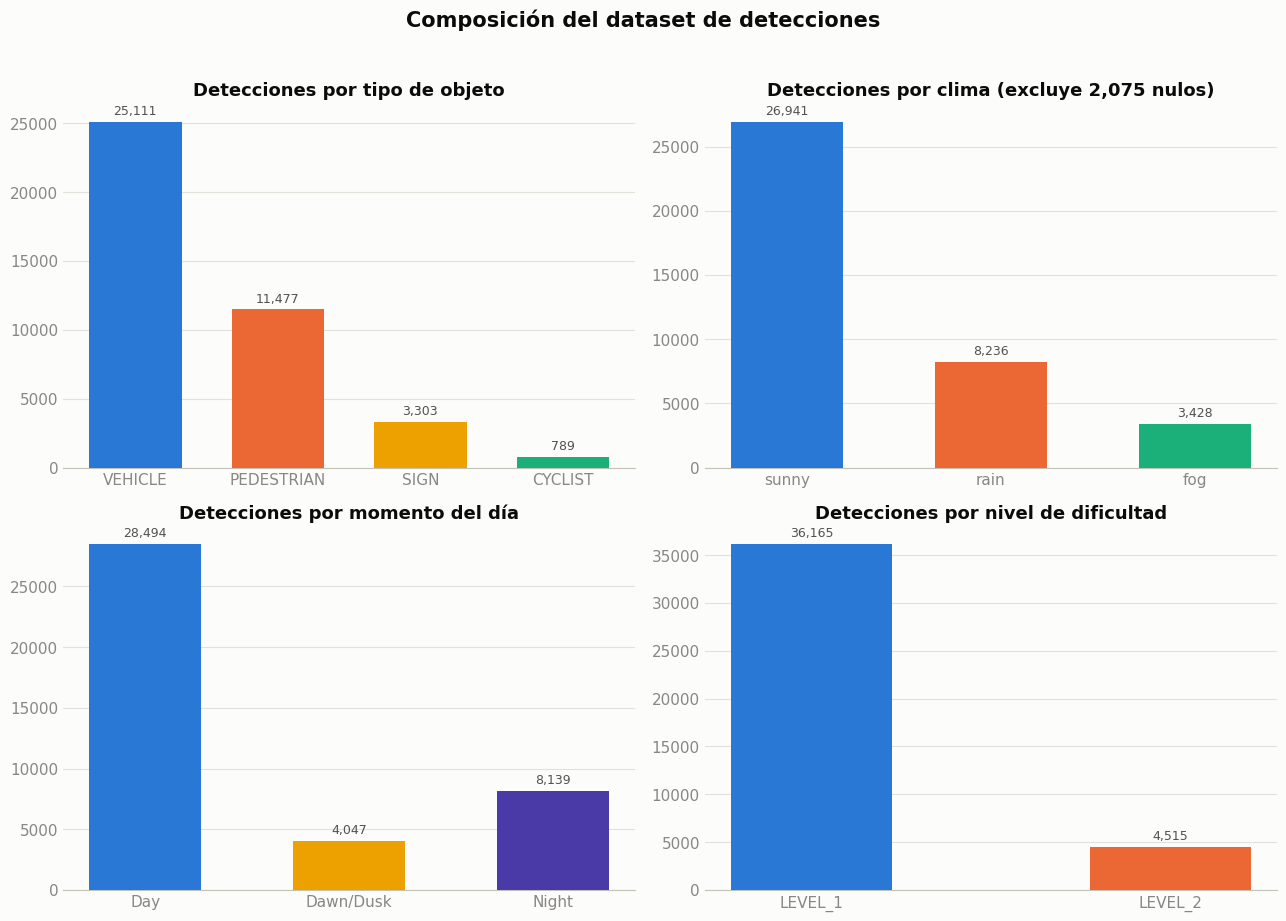

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Tipo de objeto
order = df["object_type_clean"].value_counts().index
ax = axes[0, 0]
counts = df["object_type_clean"].value_counts()
ax.bar(order, counts[order], color=[CAT[o] for o in order], width=0.65, zorder=3)
ax.set_title("Detecciones por tipo de objeto")
bar_labels(ax)
style_ax(ax)

# Clima
ax = axes[0, 1]
w_counts = df["weather_clean"].value_counts()
order_w = ["sunny", "rain", "fog"]
order_w = [o for o in order_w if o in w_counts.index]
ax.bar(order_w, w_counts[order_w], color=[CAT[o] for o in order_w], width=0.55, zorder=3)
ax.set_title(f"Detecciones por clima (excluye {df['weather_clean'].isna().sum():,} nulos)")
bar_labels(ax)
style_ax(ax)

# Momento del día
ax = axes[1, 0]
order_t = ["Day", "Dawn/Dusk", "Night"]
t_counts = df["time_of_day"].value_counts()
ax.bar(order_t, t_counts[order_t], color=[CAT[o] for o in order_t], width=0.55, zorder=3)
ax.set_title("Detecciones por momento del día")
bar_labels(ax)
style_ax(ax)

# Dificultad de detección
ax = axes[1, 1]
order_d = ["LEVEL_1", "LEVEL_2"]
d_counts = df["detection_difficulty"].value_counts()
ax.bar(order_d, d_counts[order_d], color=[CAT[o] for o in order_d], width=0.45, zorder=3)
ax.set_title("Detecciones por nivel de dificultad")
bar_labels(ax)
style_ax(ax)

fig.suptitle("Composición del dataset de detecciones", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6. Variables numéricas: distribuciones

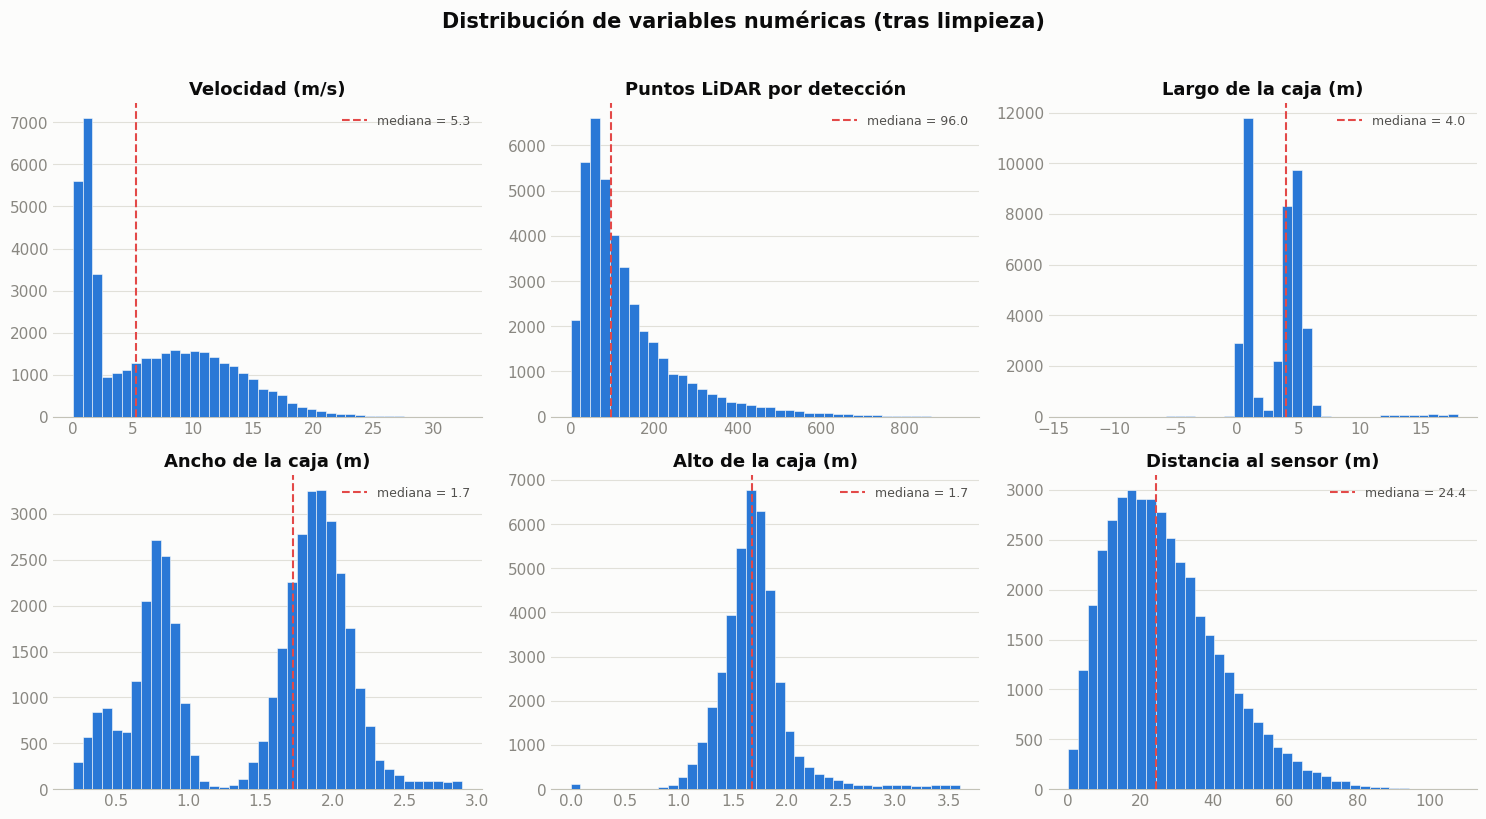

In [7]:
numeric_cols = [
    ("speed_mps_clean", "Velocidad (m/s)"),
    ("num_lidar_points", "Puntos LiDAR por detección"),
    ("box_length", "Largo de la caja (m)"),
    ("box_width", "Ancho de la caja (m)"),
    ("box_height", "Alto de la caja (m)"),
    ("distance_m", "Distancia al sensor (m)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.flat, numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#2a78d6", edgecolor=SURFACE, linewidth=0.4, zorder=3)
    ax.axvline(data.median(), color="#e34948", linewidth=1.5, linestyle="--", zorder=4,
               label=f"mediana = {data.median():.1f}")
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
    style_ax(ax)

fig.suptitle("Distribución de variables numéricas (tras limpieza)", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 7. Velocidad por tipo de objeto

`SIGN` debería tener velocidad ~0 (son estáticas); sirve como control de sanidad.

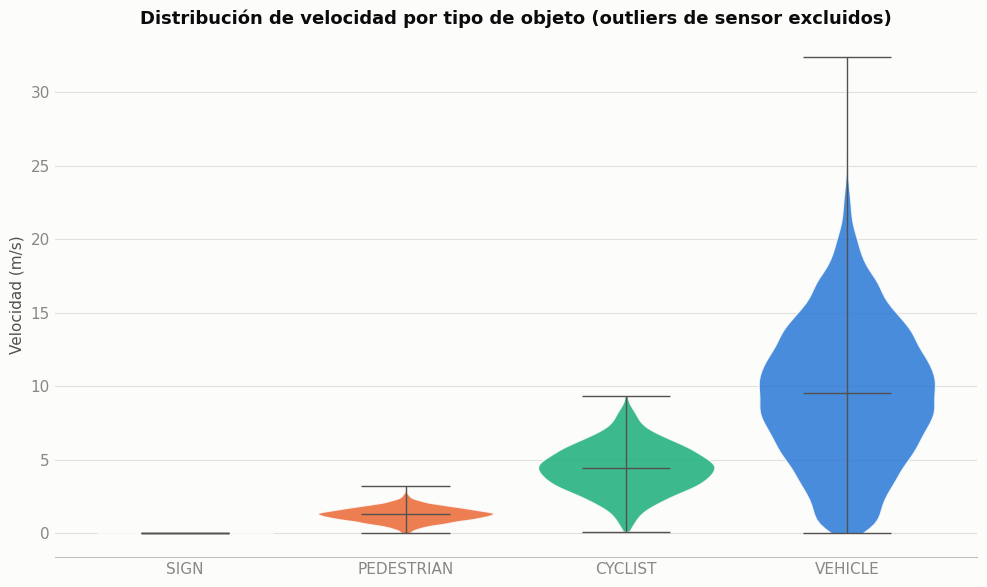

                     count  mean  median    max
object_type_clean                              
CYCLIST              772.0  4.44    4.44   9.36
PEDESTRIAN         11187.0  1.30    1.30   3.19
SIGN                3233.0  0.00    0.00   0.00
VEHICLE            24544.0  9.62    9.53  32.42


In [8]:
order = ["SIGN", "PEDESTRIAN", "CYCLIST", "VEHICLE"]
data = [df.loc[df["object_type_clean"] == o, "speed_mps_clean"].dropna() for o in order]

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, showmedians=True, widths=0.8)
for body, o in zip(parts["bodies"], order):
    body.set_facecolor(CAT[o])
    body.set_edgecolor(SURFACE)
    body.set_alpha(0.85)
for key in ("cbars", "cmins", "cmaxes", "cmedians"):
    parts[key].set_color(INK_SECONDARY)
    parts[key].set_linewidth(1)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_ylabel("Velocidad (m/s)")
ax.set_title("Distribución de velocidad por tipo de objeto (outliers de sensor excluidos)")
style_ax(ax)
fig.tight_layout()
plt.show()

print(df.groupby("object_type_clean")["speed_mps_clean"].describe()[["count", "mean", "50%", "max"]]
      .round(2).rename(columns={"50%": "median"}))

## 8. Correlación entre variables numéricas

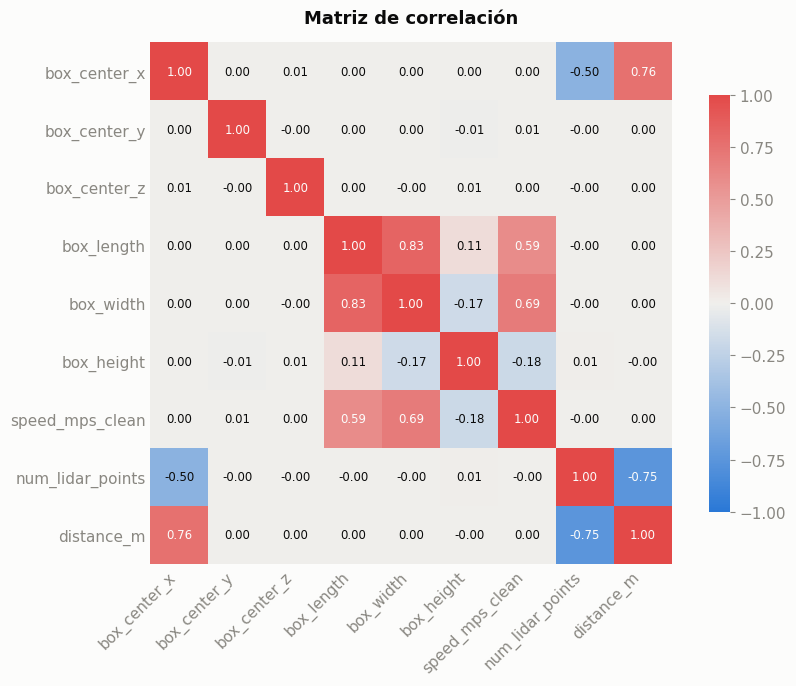

In [9]:
corr_cols = ["box_center_x", "box_center_y", "box_center_z", "box_length", "box_width",
             "box_height", "speed_mps_clean", "num_lidar_points", "distance_m"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        text_color = SURFACE if abs(v) > 0.55 else INK_PRIMARY
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8.5, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.outline.set_visible(False)
ax.set_title("Matriz de correlación", pad=14)
fig.tight_layout()
plt.show()

## 9. Puntos LiDAR: cercanía y dificultad

A menos distancia del sensor se espera más densidad de puntos LiDAR; y menos puntos debería asociarse a mayor dificultad de detección.

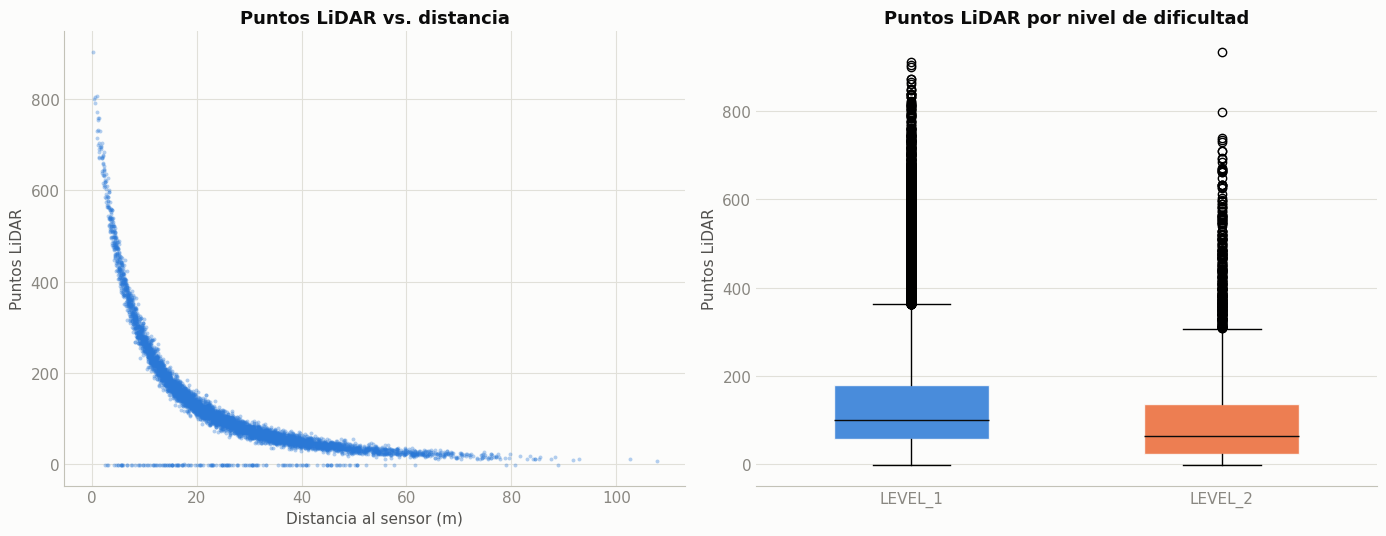

Correlación distancia vs. puntos LiDAR: -0.75


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
sample = df.sample(min(6000, len(df)), random_state=0)
ax.scatter(sample["distance_m"], sample["num_lidar_points"], s=8, alpha=0.35,
           color="#2a78d6", linewidths=0, zorder=3)
ax.set_xlabel("Distancia al sensor (m)")
ax.set_ylabel("Puntos LiDAR")
ax.set_title("Puntos LiDAR vs. distancia")
style_ax(ax, grid_axis="both")

ax = axes[1]
order_d = ["LEVEL_1", "LEVEL_2"]
data = [df.loc[df["detection_difficulty"] == d, "num_lidar_points"] for d in order_d]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops={"color": INK_PRIMARY})
for patch, d in zip(bp["boxes"], order_d):
    patch.set_facecolor(CAT[d])
    patch.set_alpha(0.85)
    patch.set_edgecolor(SURFACE)
ax.set_xticks([1, 2])
ax.set_xticklabels(order_d)
ax.set_ylabel("Puntos LiDAR")
ax.set_title("Puntos LiDAR por nivel de dificultad")
style_ax(ax)

fig.tight_layout()
plt.show()

corr_val = df["distance_m"].corr(df["num_lidar_points"])
print(f"Correlación distancia vs. puntos LiDAR: {corr_val:.2f}")

## 10. Distribución espacial de las detecciones

Vista en planta (X, Y) alrededor del sensor (origen), separada por tipo de objeto.

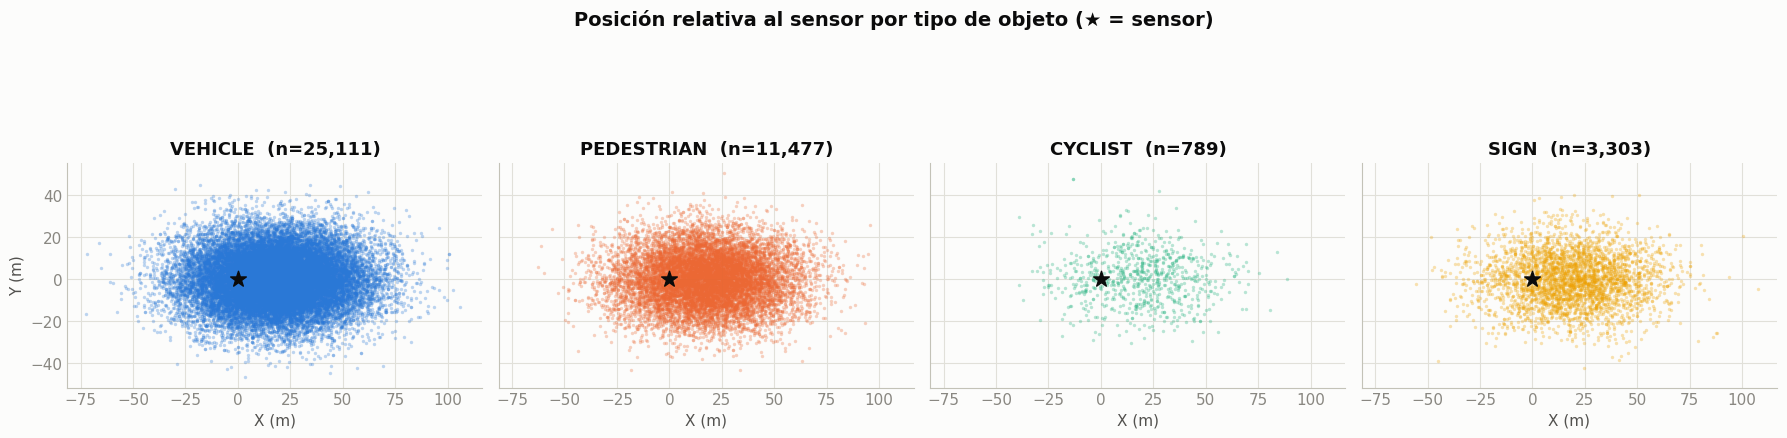

In [11]:
order = ["VEHICLE", "PEDESTRIAN", "CYCLIST", "SIGN"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharex=True, sharey=True)

for ax, o in zip(axes, order):
    sub = df[df["object_type_clean"] == o]
    ax.scatter(sub["box_center_x"], sub["box_center_y"], s=6, alpha=0.3,
               color=CAT[o], linewidths=0, zorder=3)
    ax.scatter([0], [0], marker="*", s=140, color=INK_PRIMARY, zorder=5)
    ax.set_title(f"{o}  (n={len(sub):,})")
    ax.set_xlabel("X (m)")
    ax.set_aspect("equal")
    style_ax(ax, grid_axis="both")

axes[0].set_ylabel("Y (m)")
fig.suptitle("Posición relativa al sensor por tipo de objeto (\u2605 = sensor)", fontsize=14, fontweight="bold", y=1.05)
fig.tight_layout()
plt.show()

## 11. Clima x momento del día

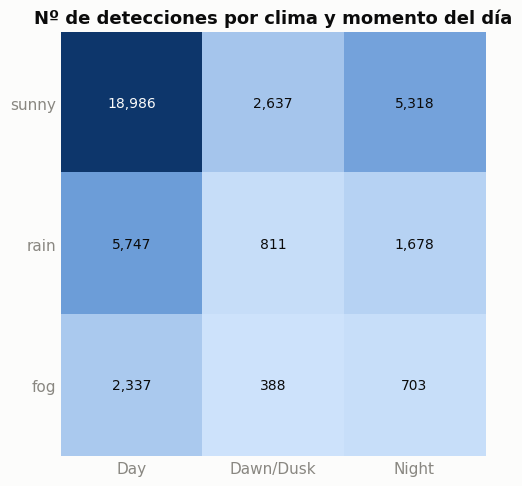

In [12]:
cross = pd.crosstab(df["weather_clean"], df["time_of_day"])
cross = cross.reindex(index=["sunny", "rain", "fog"], columns=["Day", "Dawn/Dusk", "Night"])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(cross, cmap=BLUE_SEQ)
ax.set_xticks(range(cross.shape[1]))
ax.set_yticks(range(cross.shape[0]))
ax.set_xticklabels(cross.columns)
ax.set_yticklabels(cross.index)
ax.spines[:].set_visible(False)
ax.tick_params(length=0)

vmax = cross.values.max()
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.iloc[i, j]
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=10,
                color=SURFACE if v > vmax * 0.55 else INK_PRIMARY)

ax.set_title("Nº de detecciones por clima y momento del día")
fig.tight_layout()
plt.show()

## 12. Resumen de hallazgos

Hallazgos calculados directamente sobre los datos (no texto fijo).

In [13]:
n = len(df)
dup = df.duplicated().sum()
speed_out = df["speed_outlier"].sum()
weather_null = df["weather_clean"].isna().sum()
id_dup = df["id_interno"].duplicated().sum()
top_type = df["object_type_clean"].value_counts().idxmax()
top_type_pct = df["object_type_clean"].value_counts(normalize=True).max()
corr_val = df["distance_m"].corr(df["num_lidar_points"])
sign_speed = df.loc[df["object_type_clean"] == "SIGN", "speed_mps_clean"].median()

print("HALLAZGOS CLAVE")
print("=" * 60)
print(f"1. Calidad de datos: {dup:,} filas duplicadas exactas, "
      f"{id_dup:,} id_interno repetidos, {weather_null:,} climas nulos "
      f"({weather_null / n:.1%} del total).")
print(f"2. {speed_out:,} detecciones ({speed_out / n:.2%}) tienen velocidad "
      f"imposible (>50 m/s, con un salto vacío entre ~32 y ~180 m/s): "
      f"error de sensor, no tráfico real.")
print(f"3. Las etiquetas de 'object_type' y 'weather' venían mezclando "
      f"español/inglés y mayúsculas/minúsculas; se normalizaron a "
      f"{df['object_type_clean'].nunique()} y {df['weather_clean'].nunique()} "
      f"categorías respectivamente.")
print(f"4. '{top_type}' domina el dataset ({top_type_pct:.1%} de las detecciones).")
print(f"5. Control de sanidad: los objetos 'SIGN' (estáticos) tienen velocidad "
      f"mediana de {sign_speed:.2f} m/s, como se espera de un objeto fijo.")
print(f"6. La cantidad de puntos LiDAR cae con la distancia al sensor "
      f"(correlación {corr_val:.2f}), y es visiblemente menor en detecciones "
      f"marcadas como LEVEL_2 (más difíciles).")

HALLAZGOS CLAVE
1. Calidad de datos: 480 filas duplicadas exactas, 680 id_interno repetidos, 2,075 climas nulos (5.1% del total).
2. 157 detecciones (0.39%) tienen velocidad imposible (>50 m/s, con un salto vacío entre ~32 y ~180 m/s): error de sensor, no tráfico real.
3. Las etiquetas de 'object_type' y 'weather' venían mezclando español/inglés y mayúsculas/minúsculas; se normalizaron a 4 y 3 categorías respectivamente.
4. 'VEHICLE' domina el dataset (61.7% de las detecciones).
5. Control de sanidad: los objetos 'SIGN' (estáticos) tienen velocidad mediana de 0.00 m/s, como se espera de un objeto fijo.
6. La cantidad de puntos LiDAR cae con la distancia al sensor (correlación -0.75), y es visiblemente menor en detecciones marcadas como LEVEL_2 (más difíciles).


---

## 13. ¿De qué trata este dataset?

Es un dataset **sintético al estilo Waymo Open Dataset**: cada fila es **una detección
individual** hecha por los sensores (principalmente LiDAR) de un vehículo autónomo
mientras conducía. No es una tabla de "viajes" ni de "vehículos" — es una tabla de
**objetos detectados alrededor del vehículo**, cuadro a cuadro, a lo largo de varios
recorridos de conducción ("segmentos").

Sirve típicamente para evaluar **qué tan bien detecta el sistema** distintos tipos de
objetos (vehículos, peatones, ciclistas, señales) bajo distintas condiciones
(clima, momento del día, distancia, dificultad), no para analizar tráfico o rutas.

In [14]:
print(f"Filas (detecciones):        {len(df):,}")
print(f"Columnas originales:        {df.shape[1] - 5}  (+5 columnas derivadas en la limpieza)")
print(f"Segmentos de conducción:    {df['segment_id'].nunique()} (columna 'segment_id')")
print(f"Detecciones únicas (id):    {df['id_interno'].nunique():,} de {len(df):,} filas")
print(f"Tipos de objeto:            {sorted(df['object_type_clean'].unique())}")
print(f"Condiciones de clima:       {sorted(df['weather_clean'].dropna().unique())}")
print(f"Momentos del día:           {sorted(df['time_of_day'].unique())}")
print(f"Niveles de dificultad:      {sorted(df['detection_difficulty'].unique())}")
print(f"Versión de sensor:          {df['sensor_version'].unique()} (constante -> no aporta información)")

Filas (detecciones):        40,680
Columnas originales:        16  (+5 columnas derivadas en la limpieza)
Segmentos de conducción:    153 (columna 'segment_id')
Detecciones únicas (id):    40,000 de 40,680 filas
Tipos de objeto:            ['CYCLIST', 'PEDESTRIAN', 'SIGN', 'VEHICLE']
Condiciones de clima:       ['fog', 'rain', 'sunny']
Momentos del día:           ['Dawn/Dusk', 'Day', 'Night']
Niveles de dificultad:      ['LEVEL_1', 'LEVEL_2']
Versión de sensor:          ['v2.0.1'] (constante -> no aporta información)


### Diccionario de variables

| Columna | Qué representa |
|---|---|
| `segment_id` | Recorrido/sesión de conducción al que pertenece la detección (153 segmentos). |
| `timestamp_micros` | Marca de tiempo en microsegundos del instante de la detección. |
| `id_interno` | Identificador de la detección individual. |
| `object_type` | Clase del objeto detectado: vehículo, peatón, ciclista o señal (crudo, con etiquetas inconsistentes). |
| `box_center_x/y/z` | Coordenadas (metros) del centro de la caja 3D que envuelve al objeto, relativas al sensor. |
| `box_length/width/height` | Dimensiones (metros) de esa caja 3D — el "tamaño" del objeto detectado. |
| `speed_mps` | Velocidad estimada del objeto, en metros/segundo. |
| `num_lidar_points` | Cantidad de puntos LiDAR que forman la detección — a más puntos, más "evidencia" y detección más confiable. |
| `weather` | Condición climática en el momento de la detección (crudo, con etiquetas inconsistentes). |
| `time_of_day` | Momento del día: `Day`, `Night` o `Dawn/Dusk`. |
| `detection_difficulty` | Dificultad asignada a la detección: `LEVEL_1` (fácil/estándar) o `LEVEL_2` (difícil). |
| `sensor_version` | Versión de software/hardware del sensor. Es constante en todo el dataset. |

Columnas creadas en la sección de limpieza (no vienen en el CSV original):
`object_type_clean`, `weather_clean`, `speed_mps_clean`, `speed_outlier`, `distance_m`.

### ¿Cuánta limpieza hace falta?

Estado real de los datos, resuelto o pendiente:

In [15]:
n = len(df)
issues = {
    "Filas totalmente duplicadas": df.duplicated().sum(),
    "id_interno duplicado": df["id_interno"].duplicated().sum(),
    "weather nulo": df["weather_clean"].isna().sum(),
    "speed_mps nulo": df["speed_mps"].isna().sum(),
    "speed_mps con valor imposible (outlier de sensor)": df["speed_outlier"].sum(),
    "timestamp_micros no numérico ('N/D')": (~df["timestamp_micros"].astype(str).str.isdigit()).sum(),
}

print("RESUELTO en este notebook (columnas *_clean ya lo corrigen):")
print(f"  - Etiquetas inconsistentes de 'object_type': 7 variantes -> "
      f"{df['object_type_clean'].nunique()} categorías reales.")
print(f"  - Etiquetas inconsistentes de 'weather': 11 variantes -> "
      f"{df['weather_clean'].nunique()} categorías reales.")
print(f"  - {df['speed_outlier'].sum():,} velocidades imposibles marcadas como NaN "
      f"en 'speed_mps_clean'.")
print()
print("PENDIENTE de decidir (no se puede resolver solo con más limpieza, "
      "requiere una decisión de negocio/analítica):")
for name, count in issues.items():
    print(f"  - {name}: {count:,} filas ({count / n:.2%})")
print()
any_issue = (
    df.duplicated()
    | df["id_interno"].duplicated()
    | df["weather_clean"].isna()
    | df["speed_mps"].isna()
    | df["speed_outlier"]
    | (~df["timestamp_micros"].astype(str).str.isdigit())
)
print(f"Filas afectadas por AL MENOS uno de estos problemas: "
      f"{any_issue.sum():,} de {n:,} ({any_issue.mean():.1%}).")
print()
print("Además, 'sensor_version' es constante (un solo valor en todo el dataset): "
      "no aporta información y es candidata a eliminarse si se usa este dataset "
      "para modelar.")

RESUELTO en este notebook (columnas *_clean ya lo corrigen):
  - Etiquetas inconsistentes de 'object_type': 7 variantes -> 4 categorías reales.
  - Etiquetas inconsistentes de 'weather': 11 variantes -> 3 categorías reales.
  - 157 velocidades imposibles marcadas como NaN en 'speed_mps_clean'.

PENDIENTE de decidir (no se puede resolver solo con más limpieza, requiere una decisión de negocio/analítica):
  - Filas totalmente duplicadas: 480 filas (1.18%)
  - id_interno duplicado: 680 filas (1.67%)
  - weather nulo: 2,075 filas (5.10%)
  - speed_mps nulo: 787 filas (1.93%)
  - speed_mps con valor imposible (outlier de sensor): 157 filas (0.39%)
  - timestamp_micros no numérico ('N/D'): 60 filas (0.15%)

Filas afectadas por AL MENOS uno de estos problemas: 3,647 de 40,680 (9.0%).

Además, 'sensor_version' es constante (un solo valor en todo el dataset): no aporta información y es candidata a eliminarse si se usa este dataset para modelar.


### En resumen

El dataset tiene **40,680 detecciones** repartidas en **153 recorridos de conducción**,
con **16 columnas originales** que describen, por cada objeto visto por el vehículo:
qué es (`object_type`), dónde está y qué tamaño tiene (`box_*`), a qué velocidad se
mueve (`speed_mps`), cuánta evidencia LiDAR lo respalda (`num_lidar_points`), y bajo
qué condiciones se detectó (`weather`, `time_of_day`, `detection_difficulty`).

**No es un dataset limpio de fábrica** — mezcla español/inglés y mayúsculas en las
categorías, tiene valores de velocidad físicamente imposibles, nulos en clima y
velocidad, duplicados y timestamps con placeholders. Todo eso ya se identificó y,
donde tenía una solución objetiva (normalizar etiquetas, descartar velocidades
imposibles), se corrigió en las secciones 2 y 3 de este notebook. Lo que queda
pendiente (qué hacer con los nulos, si eliminar duplicados, cómo tratar los
timestamps 'N/D') depende de para qué se vaya a usar el dataset después.